In [1]:
from scripts.circuit_frame import circuit_frame_evaluation
from circuit_generation import build_ansatz
import matplotlib.pyplot as plt
from numpy import arccos
from frame_potential_gpu import compute_frame_potential_gpu
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector


In [ ]:
acos_list = []
perfectSU4_anzatz = build_ansatz("perfect_SU4",n_qubits=8,compose_parameters=True,reps=1,acos_list=acos_list)

def parameter_composer(params):
    for i in range(len(acos_list)):
        params[acos_list[i]] = arccos(params[acos_list[i]])

F_p = compute_frame_potential_gpu(perfectSU4_anzatz, t=2, n_samples=2**(8)*2, save=False, parameter_composer=parameter_composer, circuit_info={"name": "test_SU4", "n_qubits": 8, "reps": 1}, verbose=False)


In [3]:
from math import asin, acos
import numpy as np

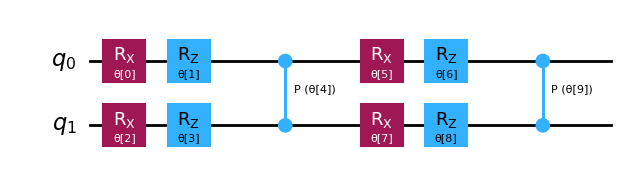

In [4]:
qc = build_ansatz(name="set", n_parameters=8, reps=1,number=3)
qc.draw("mpl")

In [5]:
def parameter_composer(theta):
    for t in range(len(theta)):
        if t == 1:
            theta[t] = acos(theta[t]/np.pi-1)

In [6]:
qc = QuantumCircuit(1)
params = ParameterVector('θ', 5)
qc.rz(params[0], 0)
qc.rx(params[1], 0)
qc.rz(params[2], 0)
F_p = compute_frame_potential_gpu(qc, t=2, n_samples=1000,verbose=False)
print("Frame potential (without parameter composer):", F_p["frame_potential"])
F_p = compute_frame_potential_gpu(qc, t=2, n_samples=1000, parameter_composer=parameter_composer, verbose=False)
print("Frame potential (with parameter composer):", F_p["frame_potential"])
F_p_3 = compute_frame_potential_gpu(qc, t=3, n_samples=100, parameter_composer=parameter_composer, verbose=False)
print("Frame potential (t=3 with parameter composer):", F_p_3["frame_potential"])                                                                                                                                                                                                                                                                                                                                                                                                                          

F_p_4 = compute_frame_potential_gpu(qc, t=4, n_samples=100, parameter_composer=parameter_composer, verbose=False)
print("Frame potential (t=4 with parameter composer):", F_p_4["frame_potential"])  

F_p_5 = compute_frame_potential_gpu(qc, t=5, n_samples=100, parameter_composer=parameter_composer, verbose=False)
print("Frame potential (t=5 with parameter composer):", F_p_5["frame_potential"])




/home/tardant/Bureau/Qiskit/.venv/lib/python3.12/site-packages/torch/xpu/__init__.py:68: UserWarning: The detected GPU (Intel(R) Iris(R) Xe Graphics) is not officially supported by PyTorch XPU. Running workloads on this device may result in unexpected behavior.
For stable and fully supported execution, please use GPUs based on Intel Arc (Alchemist) series or newer.
Refer to the hardware prerequisites for more information: https://github.com/pytorch/pytorch/blob/main/docs/source/notes/get_start_xpu.rst#hardware-prerequisite (Triggered internally at /pytorch/c10/xpu/XPUFunctions.cpp:128.)
  return torch._C._xpu_getDeviceCount()
/home/tardant/Bureau/Qiskit/architectures/Frame potential/frame_potential_gpu.py:227: RuntimeWarning: Device does not support fp64; accumulating in float32.
  warnings.warn(


Frame potential (without parameter composer): 2.0585103034973145
Frame potential (with parameter composer): 1.9981892108917236
Frame potential (t=3 with parameter composer): 4.7943196296691895
Frame potential (t=4 with parameter composer): 14.790730476379395
Frame potential (t=5 with parameter composer): 42.58253860473633


/home/tardant/Bureau/Qiskit/architectures/Frame potential/frame_potential_gpu.py:292: UserWarning: d=2 < 2t=6: large-d approximation may be inaccurate.
  warnings.warn(f"d={d} < 2t={2*t}: large-d approximation may be inaccurate.")
/home/tardant/Bureau/Qiskit/architectures/Frame potential/frame_potential_gpu.py:292: UserWarning: d=2 < 2t=8: large-d approximation may be inaccurate.
  warnings.warn(f"d={d} < 2t={2*t}: large-d approximation may be inaccurate.")
/home/tardant/Bureau/Qiskit/architectures/Frame potential/frame_potential_gpu.py:292: UserWarning: d=2 < 2t=10: large-d approximation may be inaccurate.
  warnings.warn(f"d={d} < 2t={2*t}: large-d approximation may be inaccurate.")


Composition liste for perfect_SU4 ansatz: ['identity', 'acos', 'identity', 'identity', 'acos', 'identity', 'identity', 'identity', 'identity', 'identity', 'acos', 'identity', 'identity', 'acos', 'identity']


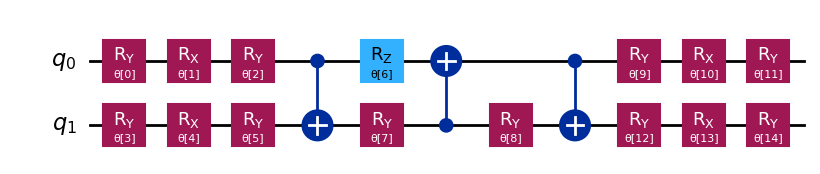

In [7]:
composer_liste = []
qc_su4 = build_ansatz(name="perfect_SU4", n_parameters=15, reps=0, parameter_prefix="θ", composition_liste=composer_liste)
print("Composition liste for perfect_SU4 ansatz:", composer_liste)
qc_su4.draw("mpl")

In [8]:
def parameter_composer_su4(theta):
    for t in range(len(theta)):
        if t in [1,4,10,13,6,7,8]:
            theta[t] = acos(theta[t]/np.pi-1)

In [9]:

F_p = compute_frame_potential_gpu(qc_su4, t=2, n_samples=1000,verbose=False)
print("Frame potential (without parameter composer):", F_p["frame_potential"])
F_p = compute_frame_potential_gpu(qc_su4, t=2, n_samples=1000, parameter_composer=parameter_composer_su4, verbose=False)
print("Frame potential (with parameter composer):", F_p["frame_potential"])

Frame potential (without parameter composer): 2.14860463142395
Frame potential (with parameter composer): 2.02264142036438


In [10]:
from circuit_generation import perfectSU4_anzatz

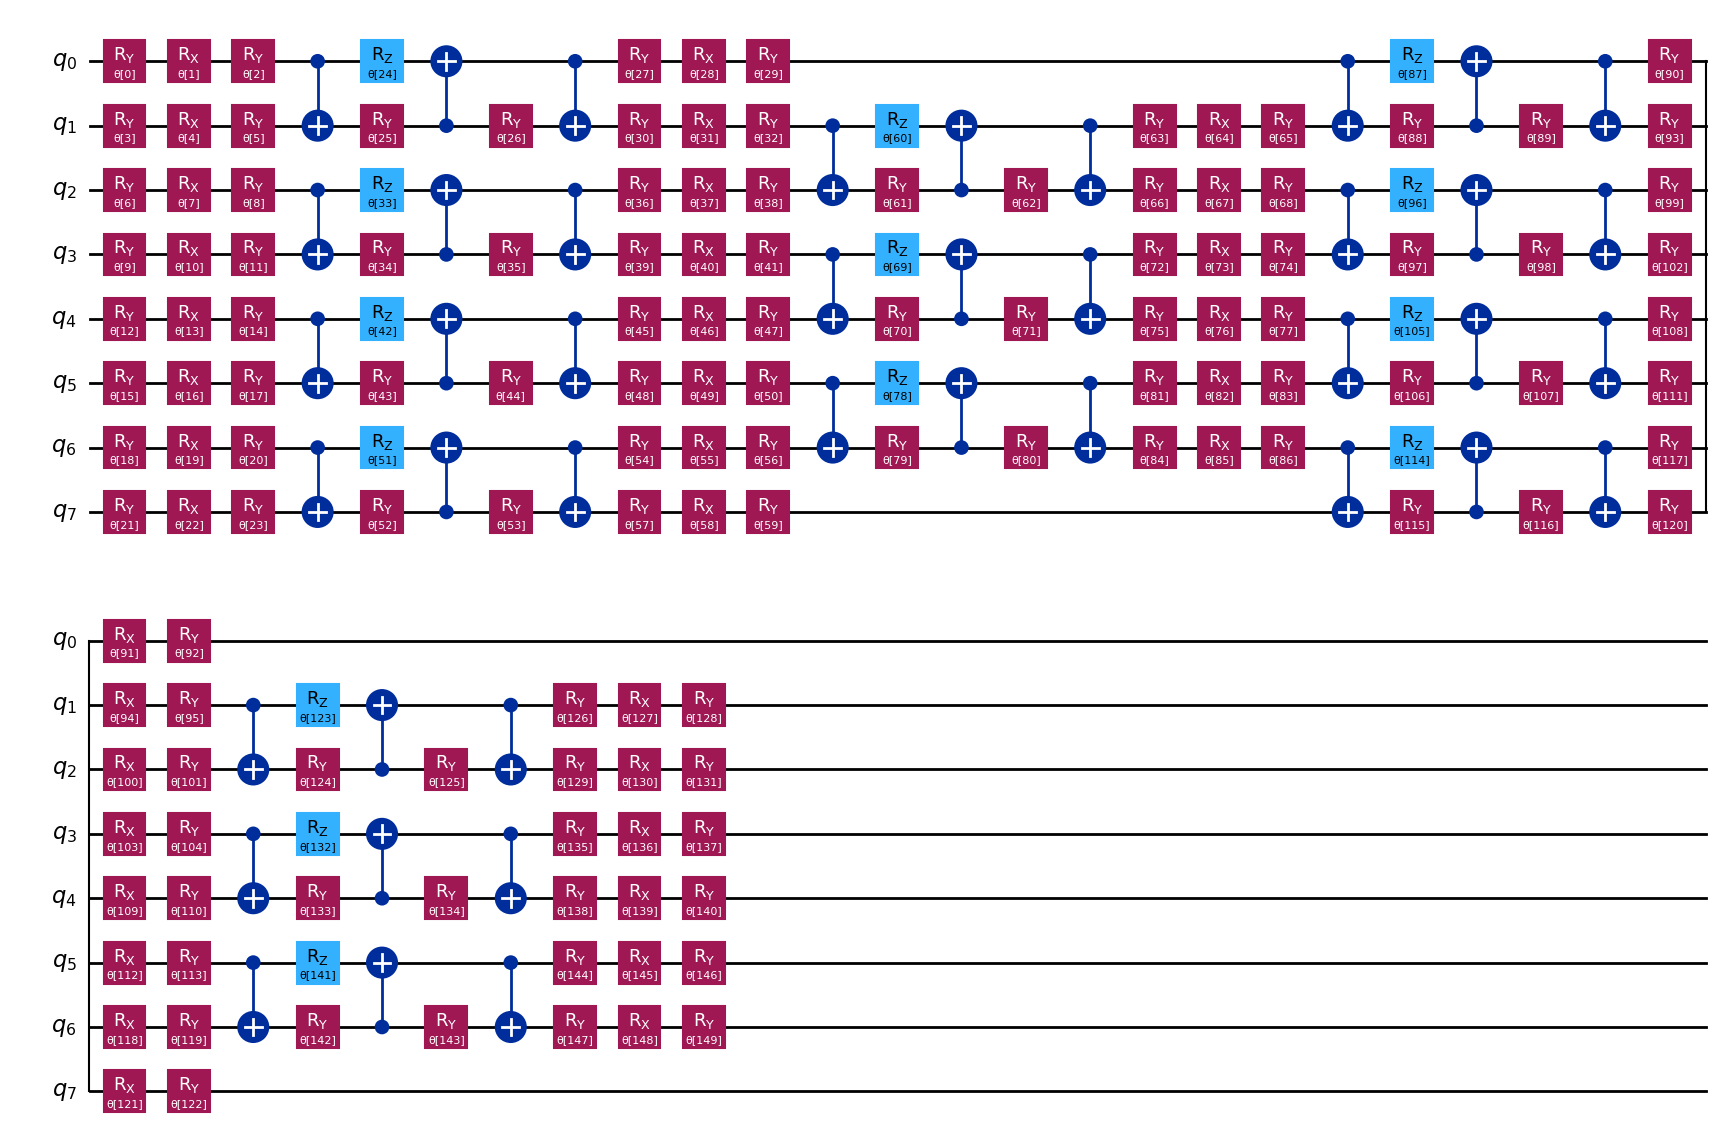

In [12]:
qc = perfectSU4_anzatz(n_qubits=8,reps=1, parameter_prefix="θ")
qc.draw("mpl")

In [16]:
from save_read_results import build_result_table
import numpy as np

In [17]:
L,var = build_result_table(path="data/results/classifier_results")


In [18]:
L

[['real_amp',
  '1',
  'artificial_dataset',
  '2026-04-30 16:04:27.182656',
  'real_amp',
  '1',
  '0',
  '2',
  '500',
  '[1.1439078991689469, 0.827016516013242, 0.9104844676164187, 1.2972105432149323, 0.6958200765254402, 1.0950412857348686, 0.8558353108141219, 0.7037073093383936, 0.7001275985139821, 0.7162825383707384, 0.6728431901066925, 0.6516701029702462, 0.6397327934421037, 0.654054915678189, 0.6484644001868809, 0.6333599858049885, 0.6294696668708449, 0.6393081179146689, 0.6291700842508737, 0.623080740045129, 0.6196776367536774, 0.6219321949283855, 0.6260576820918978, 0.6211436543621958, 0.6240876025261798, 0.6195178602291452, 0.6215076910951187, 0.6215440556298829, 0.6215161676386128, 0.6201497026764774, 0.6235144853097689, 0.6214335944673296, 0.6209446051246225, 0.6229703099150481, 0.6228592190721011, 0.620755416996445, 0.6215613224850761, 0.6214540667599938, 0.6234400098496399, 0.6213977876809648, 0.6236402413666389, 0.6213937459136835, 0.6200371946632881, 0.6214711437736931,

In [19]:
var

['anzats',
 'anzats_reps',
 'dataset_name',
 'date',
 'embeding',
 'embeding_reps',
 'layer_reps',
 'number_of_qubits',
 'number_of_samples',
 'objective_func_vals',
 'optimizer',
 'seed',
 'test_score',
 'trainging_time',
 'training_score']

In [20]:
anzats_total_rep = []
for i in range(len(L)):
    anzats_total_rep.append(int(L[i][1]) * (int(L[i][6])+1))

score = []
for i in range(len(L)):
    score.append(float(L[i][12]))

layers = []
for i in range(len(L)):
    layers.append(int(L[i][6])+1)

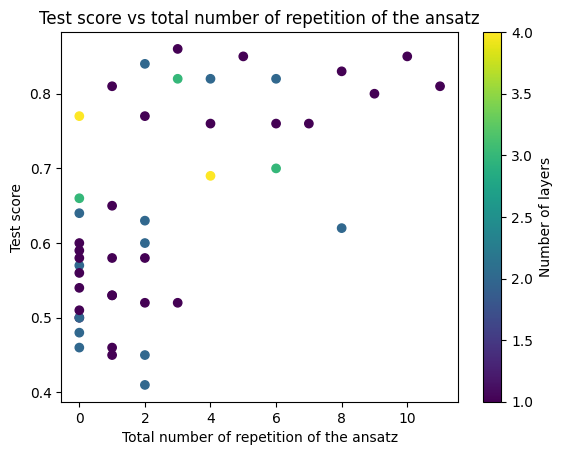

In [21]:
plt.scatter(anzats_total_rep, score , c=layers, cmap="viridis")
plt.xlabel("Total number of repetition of the ansatz")
plt.ylabel("Test score")
plt.colorbar(label="Number of layers")
plt.title("Test score vs total number of repetition of the ansatz")
plt.show()

In [22]:
import pandas as pd
from matplotlib.patches import Patch
from matplotlib import cm


In [23]:
F,var = build_result_table(path="data/results/frame_potential")


In [24]:
var

['circuit_depth',
 'd',
 'delta',
 'device',
 'dtype',
 'fidelity_error',
 'frame_potential',
 'haar_value',
 'n_parameters',
 'n_qubits',
 'n_samples',
 'name',
 'ratio',
 'reps',
 't',
 'variance']

In [40]:
df = pd.DataFrame(F, columns=var)
# get the list of the ansatz names
name = df["name"].unique()
name 

<StringArray>
[    'set_13',     'set_12',      'set_7',      'set_3',      'set_2',
     'set_10',     'set_19',     'set_11',     'set_16',      'set_4',
      'set_8',      'set_9',      'set_1',      'set_6',      'set_5',
   'real_amp',     'set_15',     'set_14', 'perfectSU4',     'set_18',
     'set_17']
Length: 21, dtype: str

In [83]:
# get F and the var in a pandas dataframe
df = pd.DataFrame(F, columns=var)

# change the type of the var column to int
df["n_parameters"] = df["n_parameters"].astype(int)
df["circuit_depth"] = df["circuit_depth"].astype(int)
df["n_qubits"] = df["n_qubits"].astype(int)
df["frame_potential"] = df["frame_potential"].astype(float)
df = df[df["n_qubits"] == 8]

df_SU4 = df[df["name"] == 'perfectSU4' ]

df = df[df["name"].str.contains("set") ]
# split the name column to get the number of the ansat and change it to int
df["name"] = df["name"].apply(lambda x: x.split("_")[1])
df["name"] = df["name"].astype(int)

df_SU4["name"] = 0

df = pd.concat([df, df_SU4], ignore_index=True)

df['t'] = df['t'].astype(int)

df.head()

,circuit_depth,d,delta,device,dtype,fidelity_error,frame_potential,haar_value,n_parameters,n_qubits,n_samples,name,ratio,reps,t,variance
0,31,256,1.9977490901947021,xpu,torch.complex64,0.057980177940477697,3.997749,2.0,64,8,512,13,1.998874545097351,2,2,881.249755859375
1,6,256,10026.1484375,xpu,torch.complex64,2582.5514515687773,10032.148438,6.0,39,8,768,7,1672.0247395833333,1,3,3933873635328.0
2,9,256,253.81796264648438,xpu,torch.complex64,4.937642155785872,254.817963,1.0,8,8,256,10,254.81796264648438,1,1,1597788.0
3,73,256,0.5601615905761719,xpu,torch.complex64,0.025715560971824255,2.560162,2.0,93,8,512,19,1.280080795288086,4,2,173.3532257080078
4,21,256,0.36631011962890625,xpu,torch.complex64,0.021293683190406455,2.366310,2.0,64,8,512,2,1.1831550598144531,4,2,118.86157989501953


In [88]:
df_t1[df_t1["name"] == 0]

,circuit_depth,d,delta,device,dtype,fidelity_error,frame_potential,haar_value,n_parameters,n_qubits,n_samples,name,ratio,reps,t,variance
288,99,256,-0.00017142295837402344,xpu,torch.complex64,0.0039029745622418985,0.000171,1.0,402,8,256,0,0.999828577041626,5,1,0.9983236789703369
290,83,256,-0.002218306064605713,xpu,torch.complex64,0.003910726165645788,0.002218,1.0,339,8,256,0,0.9977816939353943,4,1,1.0022931098937988
292,67,256,0.0010941028594970703,xpu,torch.complex64,0.003941075699408416,0.001094,1.0,276,8,256,0,1.001094102859497,3,1,1.0179102420806885
293,38,256,0.007094144821166992,xpu,torch.complex64,0.004515099920199397,0.007094,1.0,174,8,256,0,1.007094144821167,1,1,1.3360252380371094
294,51,256,0.0022063255310058594,xpu,torch.complex64,0.004008417606350328,0.002206,1.0,213,8,256,0,1.0022063255310059,2,1,1.052993893623352


In [85]:
df_t1 = df[df["t"] == 1]
fp_objectif = 1
df_t1["frame_potential"] = abs(df_t1["frame_potential"] - fp_objectif)
df_t2 = df[df["t"] == 2]
fp_objectif = 2
df_t2["frame_potential"] = abs(df_t2["frame_potential"] - fp_objectif)
df_t3 = df[df["t"] == 3]
fp_objectif = 6
df_t3["frame_potential"] = abs(df_t3["frame_potential"] - fp_objectif)
df_t1.head()

,circuit_depth,d,delta,device,dtype,fidelity_error,frame_potential,haar_value,n_parameters,n_qubits,n_samples,name,ratio,reps,t,variance
2,9,256,253.81796264648438,xpu,torch.complex64,4.937642155785872,253.817963,1.0,8,8,256,10,254.81796264648438,1,1,1597788.0
5,18,256,0.005869865417480469,xpu,torch.complex64,0.005234646479606536,0.005870,1.0,80,8,256,11,1.0058698654174805,3,1,1.7957862615585327
7,2,256,0.00040602684020996094,xpu,torch.complex64,0.12576603856719562,0.000406,1.0,16,8,256,1,1.00040602684021,1,1,1036.5892333984375
9,6,256,0.11217021942138672,xpu,torch.complex64,0.08180974390911443,0.112170,1.0,48,8,256,1,1.1121702194213867,3,1,438.62158203125
10,501,256,0.004468202590942383,xpu,torch.complex64,0.003932032167498702,0.004468,1.0,324,8,256,6,1.0044682025909424,4,1,1.0132440328598022


In [91]:
df_to_highlight

,circuit_depth,d,delta,device,dtype,fidelity_error,frame_potential,haar_value,n_parameters,n_qubits,n_samples,name,ratio,reps,t,variance
288,99,256,-0.00017142295837402344,xpu,torch.complex64,0.0039029745622418985,0.000171,1.0,402,8,256,0,0.999828577041626,5,1,0.9983236789703369
290,83,256,-0.002218306064605713,xpu,torch.complex64,0.003910726165645788,0.002218,1.0,339,8,256,0,0.9977816939353943,4,1,1.0022931098937988
292,67,256,0.0010941028594970703,xpu,torch.complex64,0.003941075699408416,0.001094,1.0,276,8,256,0,1.001094102859497,3,1,1.0179102420806885
293,38,256,0.007094144821166992,xpu,torch.complex64,0.004515099920199397,0.007094,1.0,174,8,256,0,1.007094144821167,1,1,1.3360252380371094
294,51,256,0.0022063255310058594,xpu,torch.complex64,0.004008417606350328,0.002206,1.0,213,8,256,0,1.0022063255310059,2,1,1.052993893623352


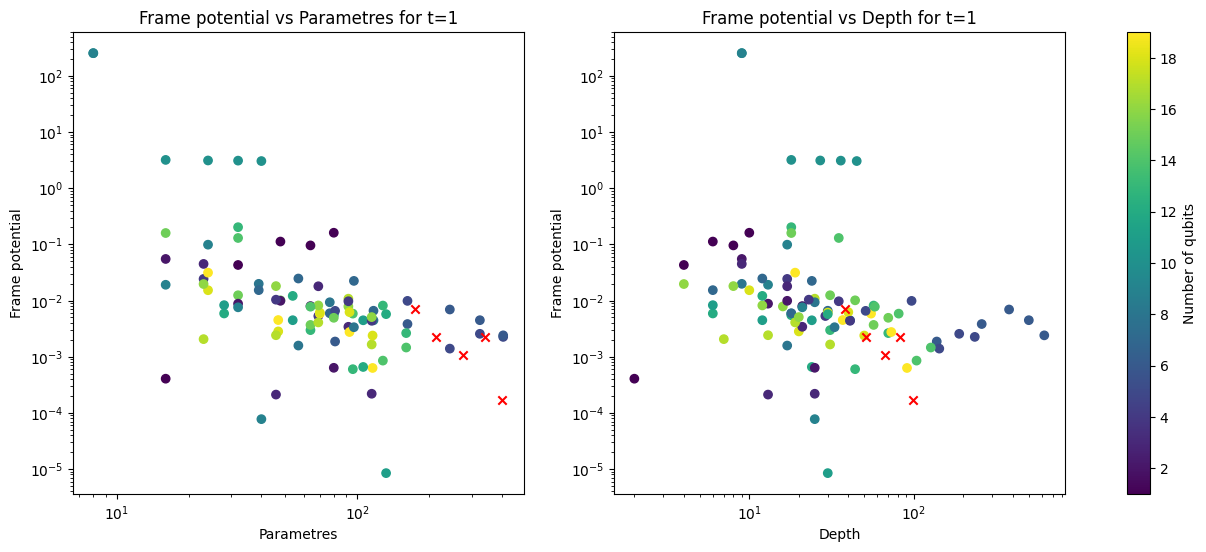

In [93]:
# plot the frame_potential depending on the parameters collored but the name of the ansatz
# use only the values where t = 1
df_to_plot = df_t1[df_t1["name"] > 0]
df_to_highlight = df_t1[df_t1["name"] == 0]
# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
# give a red colo to the perfect_SU4 ansatz and a marker "x"
ax1.scatter(df_to_plot["n_parameters"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax1.scatter(df_to_highlight["n_parameters"],df_to_highlight["frame_potential"],c="red", marker="x", label="perfect_SU4")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=1")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax2.scatter(df_to_highlight["circuit_depth"],df_to_highlight["frame_potential"],c="red", marker="x", label="perfect_SU4")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=1")
fig.colorbar(scatter2, label="Number of qubits", ax=[ax1, ax2])

plt.show()

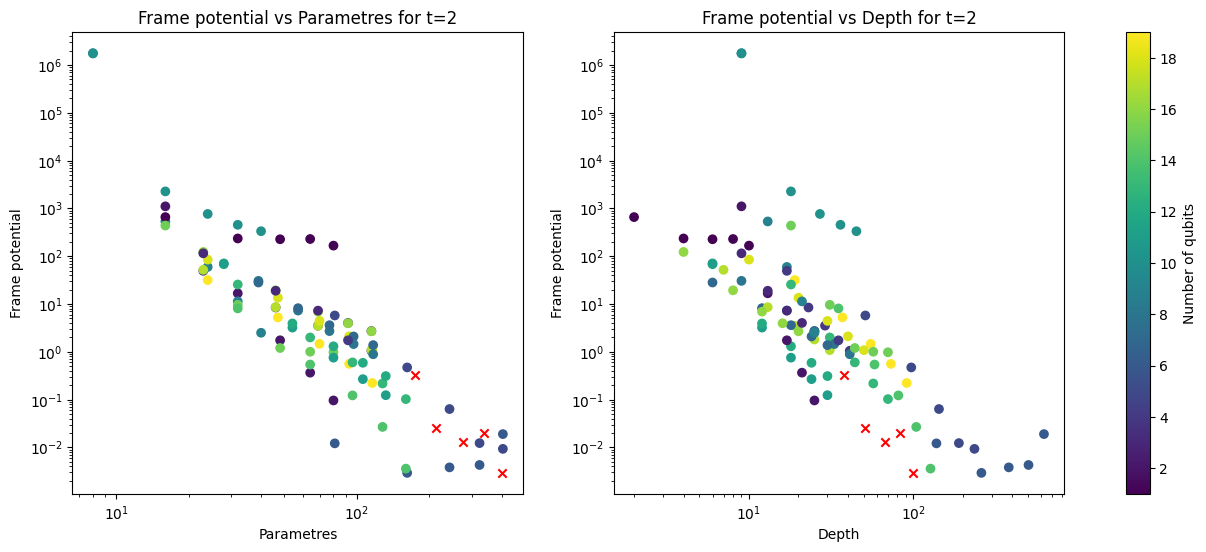

In [95]:
# plot the frame_potential depending on the parameters collored but the name of the ansatz
# use only the values where t = 1
df_to_plot = df_t2[df_t2["name"] > 0]
df_to_highlight = df_t2[df_t2["name"] == 0 ]
# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
ax1.scatter(df_to_plot["n_parameters"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax1.scatter(df_to_highlight["n_parameters"],df_to_highlight["frame_potential"],c="red", marker="x", label="perfect_SU4")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=2")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax2.scatter(df_to_highlight["circuit_depth"],df_to_highlight["frame_potential"],c="red", marker="x", label="perfect_SU4")

ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=2")
fig.colorbar(scatter2, label="Number of qubits", ax=[ax1, ax2])

plt.show()

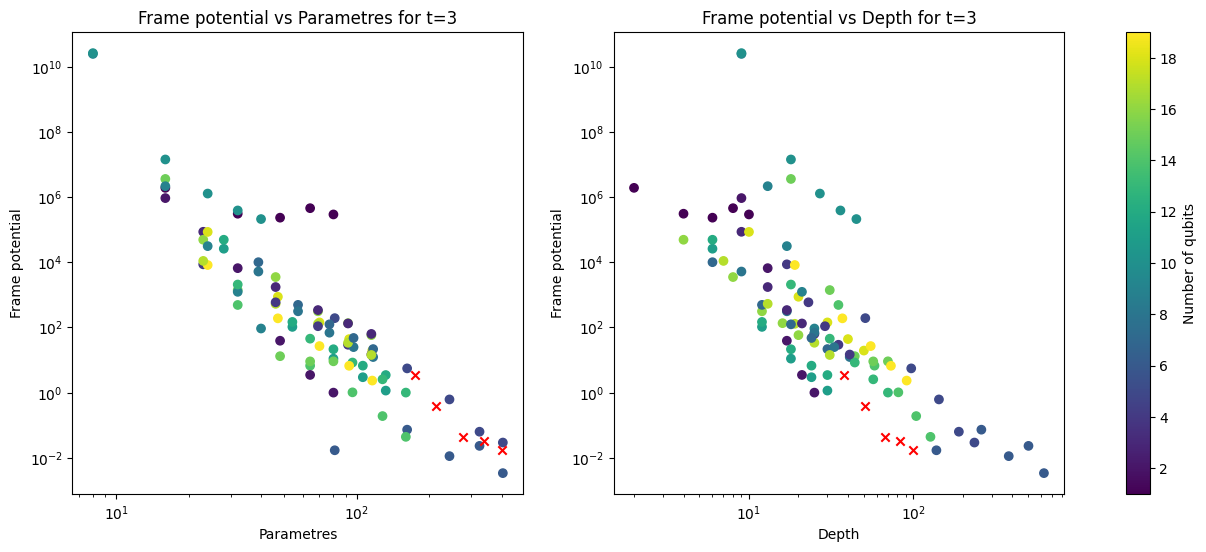

In [97]:
# plot the frame_potential depending on the parameters collored but the name of the ansatz
# use only the values where t = 1
df_to_plot = df_t3[df_t3["name"] > 0]
df_to_highlight = df_t3[df_t3["name"] == 0 ]
# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
ax1.scatter(df_to_plot["n_parameters"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax1.scatter(df_to_highlight["n_parameters"],df_to_highlight["frame_potential"],c="red", marker="x", label="perfect_SU4")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=3")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax2.scatter(df_to_highlight["circuit_depth"],df_to_highlight["frame_potential"],c="red", marker="x", label="perfect_SU4")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=3")
fig.colorbar(scatter2, label="Number of qubits", ax=[ax1, ax2])

plt.show()

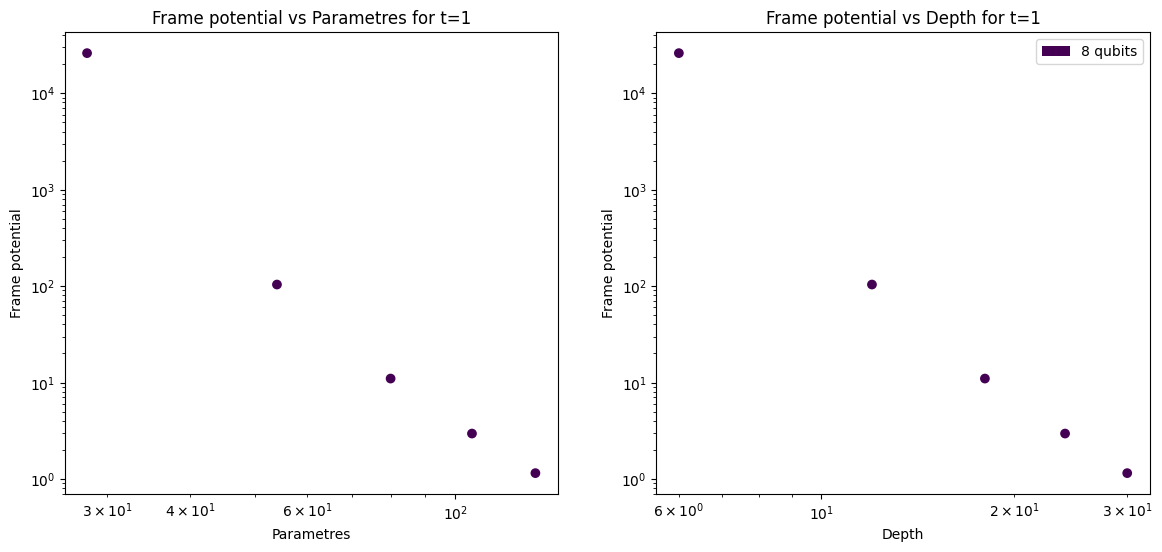

In [ ]:



df_to_plot = df_t3[df_t3["name"] == 11]

# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
ax1.scatter(df_to_plot["n_parameters"],df_to_plot["frame_potential"],c=df_to_plot["n_qubits"], cmap="viridis")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=1")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["frame_potential"],c=df_to_plot["n_qubits"], cmap="viridis")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=1")

unique_vals = sorted(df_to_plot["n_qubits"].unique())
colors = cm.viridis(np.linspace(0, 1, len(unique_vals)))
legend_elements = [Patch(facecolor=colors[i], label=f"{int(val)} qubits") 
                   for i, val in enumerate(unique_vals)]
ax2.legend(handles=legend_elements, loc='best')
plt.show()